# Homework 3 - Simple Momentum Strategy

1. Download daily price data for QQQ, TLT, GLD, RWO from yahoo finance since 2016-01-01. Using the adjusted close price data, compute daily returns. This should be a DataFrame with index=date, columns=ticker and values=daily returns.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np

In [2]:
univ = ['QQQ','TLT','GLD','RWO']
stock_px = yf.download(univ, start='2016-01-01')

[*********************100%***********************]  4 of 4 completed


In [3]:
stock_px

Price            Close                                          High  \
Ticker             GLD         QQQ        RWO        TLT         GLD   
Date                                                                   
2016-01-04  102.889999  101.717308  32.088959  90.984589  103.669998   
2016-01-05  103.180000  101.540787  32.477745  90.617500  103.459999   
2016-01-06  104.669998  100.565453  32.227806  91.838638  104.800003   
2016-01-07  106.150002   97.416405  31.651552  92.003433  106.239998   
2016-01-08  105.680000   96.617516  31.172525  92.415451  105.800003   
...                ...         ...        ...        ...         ...   
2026-06-12  386.540009  721.340027  50.259998  85.769997  388.769989   
2026-06-15  396.549988  744.000000  49.860001  85.720001  401.000000   
2026-06-16  397.630005  729.859985  50.040001  86.190002  398.959991   
2026-06-17  388.600006  722.510010  48.959999  86.330002  402.040009   
2026-06-18  387.119995  740.619995  48.930000  86.750000  392.500000   

Price                                                Low              \
Ticker             QQQ        RWO        TLT         GLD         QQQ   
Date                                                                   
2016-01-04  101.810199  32.186156  91.733741  102.489998  100.435394   
2016-01-05  102.348954  32.574942  91.022043  102.930000  101.067040   
2016-01-06  101.150673  32.318061  91.861118  103.930000   99.775868   
2016-01-07   99.664402  32.005626  92.093334  105.190002   97.360664   
2016-01-08   98.735464  31.720993  92.497858  105.040001   96.515333   
...                ...        ...        ...         ...         ...   
2026-06-12  724.010010  50.410000  85.830002  383.350006  711.280029   
2026-06-15  744.760010  50.529999  86.110001  396.149994  737.380005   
2026-06-16  744.219971  50.259998  86.379997  395.820007  729.640015   
2026-06-17  735.679993  49.950001  86.589996  387.079987  720.849976   
2026-06-18  741.820007  49.189999  87.180000  385.600006  732.510010   

Price                                   Open                         \
Ticker            RWO        TLT         GLD         QQQ        RWO   
Date                                                                  
2016-01-04  31.762653  90.887201  103.129997  101.670859  32.012589   
2016-01-05  32.082014  90.392758  103.129997  102.218905  32.082014   
2016-01-06  32.095897  91.434101  104.370003   99.775868  32.179208   
2016-01-07  31.602954  91.239300  105.830002   98.419639  31.866775   
2016-01-08  31.103097  91.568911  105.480003   98.122370  31.720993   
...               ...        ...         ...         ...        ...   
2026-06-12  49.880001  85.410004  385.730011  717.609985  49.880001   
2026-06-15  49.840000  85.669998  399.489990  738.099976  50.490002   
2026-06-16  49.830002  85.930000  397.829987  742.250000  49.970001   
2026-06-17  48.790001  85.930000  397.820007  735.190002  49.950001   
2026-06-18  48.810001  86.650002  391.239990  737.200012  49.009998   

Price                    Volume                              
Ticker            TLT       GLD       QQQ     RWO       TLT  
Date                                                         
2016-01-04  91.344184   6440000  50807600  787600  10591900  
2016-01-05  90.557567   3500300  38795200  243700   6242600  
2016-01-06  91.621389   9316600  41891100  148400   8916900  
2016-01-07  91.906045  11730400  61386300  131800  10202200  
2016-01-08  91.718739   7678200  69344000  244400   9577200  
...               ...       ...       ...     ...       ...  
2026-06-12  85.639999   7532600  51168400   41000  23092600  
2026-06-15  85.959999  10477100  46710200   23500  17632700  
2026-06-16  85.959999   6004000  45348700   22300  26472500  
2026-06-17  86.330002  13343000  51669300   40000  34507500  
2026-06-18  87.070000   7627300  50154600   48700  32350900  

[2630 rows x 20 columns]

In [37]:
# daily_returns = stock_px['Close'] - stock_px['Close'].shift(1)

daily_returns = stock_px['Close'] / stock_px['Close'].shift(1) -1

In [38]:
daily_returns

Ticker,GLD,QQQ,RWO,TLT
Date,,,,
2016-01-04,NaN,NaN,NaN,NaN
2016-01-05,0.002819,-0.001735,0.012116,-0.004034
2016-01-06,0.014441,-0.009606,-0.007695,0.013475
2016-01-07,0.014140,-0.031313,-0.017880,0.001794
2016-01-08,-0.004428,-0.008201,-0.015135,0.004479
...,...,...,...,...
2026-06-12,0.000569,0.005885,0.008832,-0.002443
2026-06-15,0.025896,0.031414,-0.007959,-0.000583
2026-06-16,0.002724,-0.019005,0.003610,0.005483


In [39]:
stock_px['Close'].shift(1)

Ticker,GLD,QQQ,RWO,TLT
Date,,,,
2016-01-04,NaN,NaN,NaN,NaN
2016-01-05,102.889999,101.717285,32.088943,90.984581
2016-01-06,103.180000,101.540794,32.477730,90.617508
2016-01-07,104.669998,100.565422,32.227798,91.838623
2016-01-08,106.150002,97.416405,31.651556,92.003418
...,...,...,...,...
2026-06-12,386.320007,717.119995,49.820000,85.980003
2026-06-15,386.540009,721.340027,50.259998,85.769997
2026-06-16,396.549988,744.000000,49.860001,85.720001


2. Compute the signal. Complete the compute_momentum function which computes a simple momentum signal. The function takes in a DataFrame with index = date, columns=ticker and values containing daily returns. It returns a new DataFrame with index = date, columns=ticker and values containing the momentum signal for the ticker on that day. The momentum signal for each ticker is defined as the annualized sharpe ratio of the past 252 days.

In [40]:
def compute_momentum(ret):
    ret_mean = ret.rolling(window=252, min_periods=252).mean()
    ret_std = ret.rolling(window=252, min_periods=252).std()

    momentum = ret_mean/ret_std * np.sqrt(252)
    # fill out the body here
    # return a DataFrame "momentum" containing a simple momentum indicator 
    return momentum

In [41]:
momentum= compute_momentum(daily_returns)

3. Create a portfolio. Complete the function compute_portfolio. This function takes as input the DataFrame "momentum" from above. It returns a new DataFrame "portfolio" which has the same index/columns and has as values portfolio weights. The weights are computed as follows. On each date, equal-weight long the tickers with a momentum signal above 1.

In [42]:
def compute_portfolio(momentum):
    portfolio = (momentum > 1)*1
    ### labels each company whose momentum is greater than 1 and multiply it to 1. 
    portfolio = portfolio.div(portfolio.abs().sum(1),0)
    ##divide each cell by the total across columns, normalizing each cell value. 
    return portfolio
    
    # fill out the body here
    # return a DataFrame "portfolio" containing portfolio weights
    return portfolio

In [43]:
portfolio = compute_portfolio(momentum)
portfolio

Ticker,GLD,QQQ,RWO,TLT
Date,,,,
2016-01-04,NaN,NaN,NaN,NaN
2016-01-05,NaN,NaN,NaN,NaN
2016-01-06,NaN,NaN,NaN,NaN
2016-01-07,NaN,NaN,NaN,NaN
2016-01-08,NaN,NaN,NaN,NaN
...,...,...,...,...
2026-06-12,0.000000,0.500000,0.500000,0.0
2026-06-15,0.333333,0.333333,0.333333,0.0
2026-06-16,0.000000,0.500000,0.500000,0.0


4. Portfolio returns. Using the "portfolio" returned in part(3) and the returns generated in part(1), compute the returns to the simple momentum strategy. 
- What is the annualized sharpe ratio of the strategy? 
- How about the annualized sharpe ratio within each year? 
- How correlated is the strategy with the underlying tickers?
- Plot the cumulative sum of the returns through time

In [44]:
strat_ret = (portfolio.shift()*daily_returns).sum(1)
### It works out the sums across all assets to get 
### a single daily return strategy return per date
strat_ret = strat_ret.loc[momentum.dropna().index[0]:]

### It drops all NA containing rows where momentums are NA. 
### 

In [46]:
strat_ret.mean()/strat_ret.std()*np.sqrt(252)

np.float64(1.2128742929754663)

In [47]:
sharpe = lambda x : x.mean()/x.std()*np.sqrt(252)
### The average daily return of the strategy
### standard deviation represents risks.
### The entire formula represents sharpe ratio.



In [48]:
strat_ret.groupby([x.year for x in strat_ret.index]).apply(sharpe)

2017    2.670437
2018   -0.024998
2019    1.015495
2020    1.528308
2021    1.411044
2022   -0.737294
2023    1.171863
2024    1.802066
2025    2.553750
2026    0.950910
dtype: float64

In [50]:
daily_returns.corrwith(strat_ret)
##How correlated is the strategy with the underlying tickers?
### The correlation between strategy with the tickers.

Ticker
GLD    0.560543
QQQ    0.401280
RWO    0.234576
TLT    0.172776
dtype: float64

<Axes: xlabel='Date'>

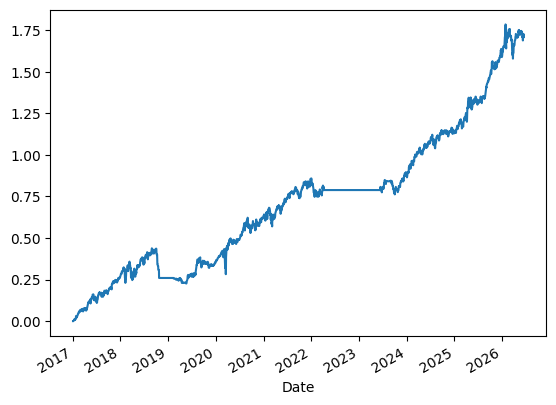

In [51]:
strat_ret.cumsum().plot()
###Cumulative returns are plotted